In [57]:
!pip install pandas numpy statsforecast mlforecast catboost datasetsforecast utilsforecast

In [4]:
!pip install tsfeatures scikit-learn

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 233.8/233.8 kB 14.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.3/981.3 kB 41.1 MB/s eta 0:00:00
  Created wheel for supersmoother: filename=supersmoother-0.4-py3-none-any.whl size=16146 sha256=0acc48890fe21895f157e085018bc8529394ccf045f9738f8b1191799e9c7359
  Stored in directory: /root/.cache/pip/wheels/69/4a/ff/05c85ded597955df839bedebe6dca56297c2568c04881d2e70
Successfully built supersmoother


In [58]:
import pandas as pd
import numpy as np
from datasetsforecast.m4 import M4
from tsfeatures import tsfeatures
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from statsforecast import StatsForecast
from tsfeatures import tsfeatures, stl_features
from statsforecast.models import Naive, SeasonalNaive, AutoTheta, AutoETS
from mlforecast import MLForecast
from mlforecast.target_transforms import Differences, LocalBoxCox
from catboost import CatBoostRegressor
from utilsforecast.losses import smape, mase
from utilsforecast.evaluation import evaluate

In [64]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns

In [59]:
np.random.seed(42)

In [60]:
Y_df, _, _ = M4.load('./data', 'Monthly')

In [86]:
HORIZON = 12
SEASONALITY = 12

Тут будем смотреть на совсем чуть-чуть(150) просто чтобы провести первоначальные быстрые эксперименты и не ждать по долгу

In [61]:
selected_ids = np.random.choice(Y_df['unique_id'].unique(), size=150, replace=False)
df = Y_df[Y_df['unique_id'].isin(selected_ids)].copy()

In [10]:
df

,unique_id,ds,y
1529,M10000,1,4060.0
1530,M10000,2,4230.0
1531,M10000,3,4480.0
1532,M10000,4,4600.0
1533,M10000,5,4400.0
...,...,...,...
11242365,M9964,83,610.0
11242366,M9964,84,520.0
11242367,M9964,85,460.0
11242368,M9964,86,470.0


In [62]:
features_df = tsfeatures(df, freq=12, features=[stl_features])
features_df = features_df.dropna()
df = df[df['unique_id'].isin(features_df['unique_id'])].copy()

In [63]:
scaler = StandardScaler()
scaled_features = scaler.fit_transform(features_df.drop(columns=['unique_id']))

Теперь самое интересное. Хочется понять, как подобрать количесто кластеров для kmeans. Вообще перевоначальное, что хочется
это 3, но давайте еще попробует 2/4

In [70]:
kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
features_df['cluster'] = kmeans.fit_predict(scaled_features)

In [72]:
def draw_clusters(scaled_features, features_df):
  pca = PCA(n_components=2)
  pca_coords = pca.fit_transform(scaled_features)

  features_df['pca_1'] = pca_coords[:, 0]
  features_df['pca_2'] = pca_coords[:, 1]

  plt.figure(figsize=(10, 6))
  sns.scatterplot(
      data=features_df,
      x='pca_1',
      y='pca_2',
      hue='cluster',
      palette='Set1',
      s=100,
      alpha=0.8
  )

  plt.legend(title='Кластер')
  plt.show()

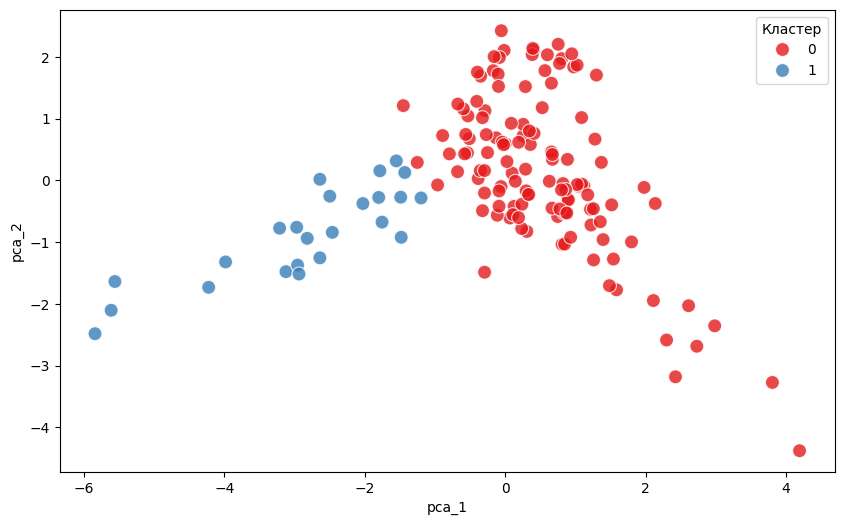

In [73]:
draw_clusters(scaled_features, features_df)

In [74]:
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
features_df['cluster'] = kmeans.fit_predict(scaled_features)

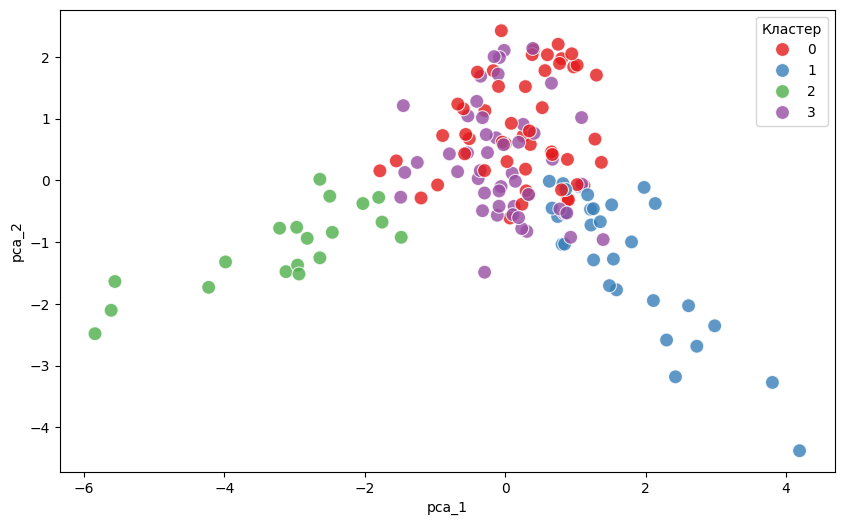

In [75]:
draw_clusters(scaled_features, features_df)

In [76]:
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
features_df['cluster'] = kmeans.fit_predict(scaled_features)

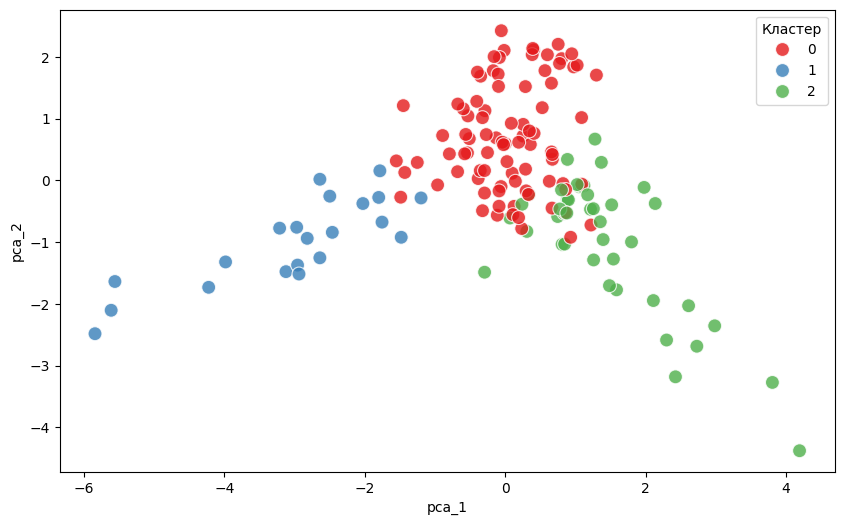

In [77]:
draw_clusters(scaled_features, features_df)

Мне кажется, что в итоге 3 кластера выглядят максимально гармонично при такой отрисовке

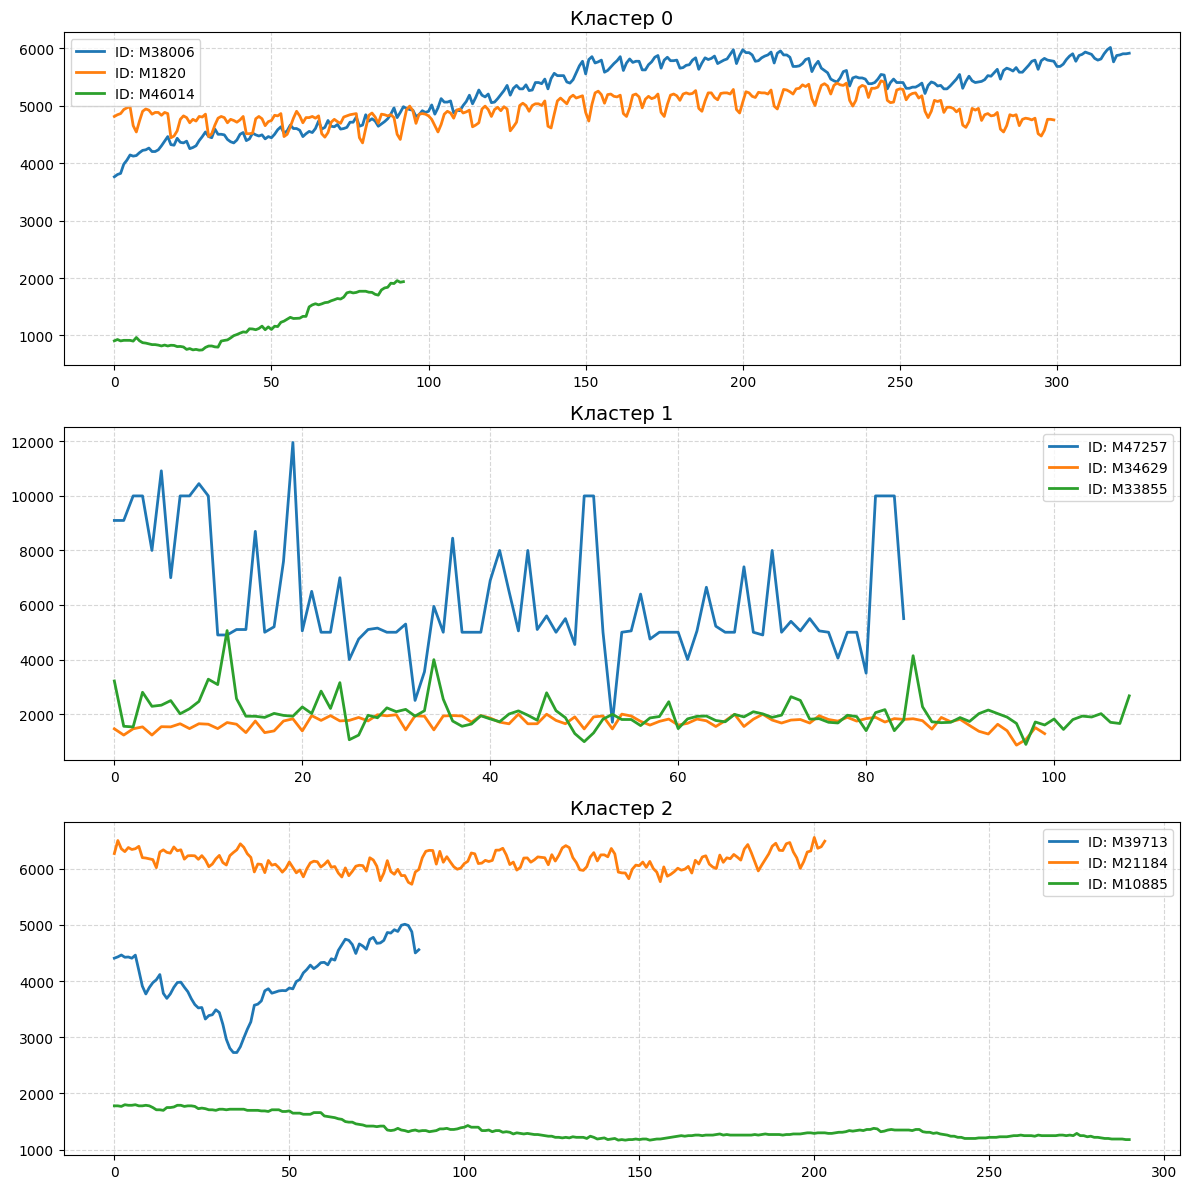

In [81]:
n_clusters = features_df['cluster'].nunique()
fig, axes = plt.subplots(n_clusters, 1, figsize=(12, 4 * n_clusters), sharex=False)
if n_clusters == 1:
    axes = [axes]

for cluster_id, ax in zip(range(n_clusters), axes):
    cluster_uids = features_df[features_df['cluster'] == cluster_id]['unique_id'].unique()
    sample_uids = np.random.choice(cluster_uids, size=min(3, len(cluster_uids)), replace=False)

    for uid in sample_uids:
        ts_data = df[df['unique_id'] == uid]
        ax.plot(range(len(ts_data)), ts_data['y'], label=f'ID: {uid}', linewidth=2)

    ax.set_title(f'Кластер {cluster_id}', fontsize=14)
    ax.legend()
    ax.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

Отрисовали ряды разных типов

In [82]:
df = df.merge(features_df[['unique_id', 'cluster']], on='unique_id', how='left')


In [83]:
df.head(3)

,unique_id,ds,y,cluster
0,M10000,1,4060.0,2
1,M10000,2,4230.0,2
2,M10000,3,4480.0,2


Тут у нас заметно, что дата - это просто интовые значения, добавим еще немного преобразований

In [84]:
df['ds'] = df.groupby('unique_id').cumcount() + 1

In [85]:
df.head(3)

,unique_id,ds,y,cluster
0,M10000,1,4060.0,2
1,M10000,2,4230.0,2
2,M10000,3,4480.0,2


In [87]:
test_df = df.groupby('unique_id').tail(HORIZON)
train_df = df.drop(test_df.index)

напищем свой Log1pTransform, остальные будем использовать из коробки

In [88]:
import numpy as np
from mlforecast.target_transforms import BaseTargetTransform

class Log1pTransform(BaseTargetTransform):
    def fit_transform(self, df):
        df = df.copy()
        df['y'] = np.log1p(df['y'])
        return df

    def inverse_transform(self, df):
        df = df.copy()
        cols_to_transform = df.columns.drop(['unique_id', 'ds'], errors='ignore')
        for col in cols_to_transform:
            df[col] = np.expm1(df[col])
        return df


In [89]:
transforms_dict = {
    "Target_None": [],
    "Target_Log1p": [Log1pTransform()],
    "Target_BoxCox": [LocalBoxCox()],
    "Target_Diff": [Differences([1])]
}

In [90]:
cb_model = CatBoostRegressor(verbose=False, random_seed=42, iterations=200)
ml_preds_list = []

for name, transform in transforms_dict.items():
    mlf = MLForecast(
        models={name: cb_model},
        freq=1,
        lags=[1, 2, 3, 6, 12],
        target_transforms=transform
    )

    mlf.fit(train_df[['unique_id', 'ds', 'y']], id_col='unique_id', time_col='ds', target_col='y')
    preds = mlf.predict(h=HORIZON)
    ml_preds_list.append(preds)

In [92]:
ml_preds_list[0]

,unique_id,ds,Target_None
0,M10000,76,1737.431039
1,M10000,77,1745.607031
2,M10000,78,1837.325328
3,M10000,79,1873.228534
4,M10000,80,1903.438357
...,...,...,...
1795,M9964,83,557.143542
1796,M9964,84,557.143542
1797,M9964,85,530.831407
1798,M9964,86,530.831407


In [93]:
sf = StatsForecast(
    models=[Naive(), SeasonalNaive(season_length=SEASONALITY), AutoETS(season_length=SEASONALITY)],
    freq=1,
    n_jobs=-1
)
sf.fit(train_df[['unique_id', 'ds', 'y']])
baselines_preds = sf.predict(h=HORIZON)

In [94]:
all_preds = baselines_preds.reset_index()
for ml_pred in ml_preds_list:
    all_preds = all_preds.merge(ml_pred, on=['unique_id', 'ds'], how='left')

results_df = test_df[['unique_id', 'ds', 'y', 'cluster']].merge(all_preds, on=['unique_id', 'ds'], how='left')

In [95]:
from functools import partial

In [96]:
mase_with_seasonality = partial(mase, seasonality=SEASONALITY)
mase_with_seasonality.__name__ = 'mase'

metrics = [smape, mase_with_seasonality]
evaluation = evaluate(
    df=results_df,
    metrics=metrics,
    train_df=train_df,
    models=results_df.columns.drop(['unique_id', 'ds', 'y', 'cluster']).tolist()
)

In [97]:
evaluation = evaluation.merge(features_df[['unique_id', 'cluster']], on='unique_id', how='left')
final_report = evaluation.groupby(['metric', 'cluster']).mean(numeric_only=True).round(3)

In [98]:
final_report

index  Naive  SeasonalNaive  AutoETS  Target_None  \
metric cluster                                                       
mase   0        18.399  1.419          1.063    0.878        1.235   
       1         2.688  1.219          1.169    1.061        1.041   
       2        13.174  0.793          1.058    0.722        0.971   
smape  0         0.616  0.070          0.078    0.063        0.073   
       1         0.469  0.172          0.168    0.152        0.148   
       2         0.583  0.046          0.055    0.047        0.050   

                Target_Log1p  Target_BoxCox  Target_Diff  
metric cluster                                            
mase   0               1.229            inf        1.133  
       1               0.953            inf        1.007  
       2               0.984            inf        0.770  
smape  0               0.073          0.532        0.068  
       1               0.139          0.660        0.150  
       2               0.050          0.618        0.047